# Import Libraries and Dataset

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

In [50]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [52]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Data Preprocessing

## Filling missing values

In [53]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

(array([1.5304e+04, 4.1460e+03, 6.8200e+02, 1.7700e+02, 7.0000e+01,
        2.3000e+01, 1.8000e+01, 8.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([1.0000e+00, 6.4540e+02, 1.2898e+03, 1.9342e+03, 2.5786e+03,
        3.2230e+03, 3.8674e+03, 4.5118e+03, 5.1562e+03, 5.8006e+03,
        6.4450e+03]),
 <BarContainer object of 10 artists>)

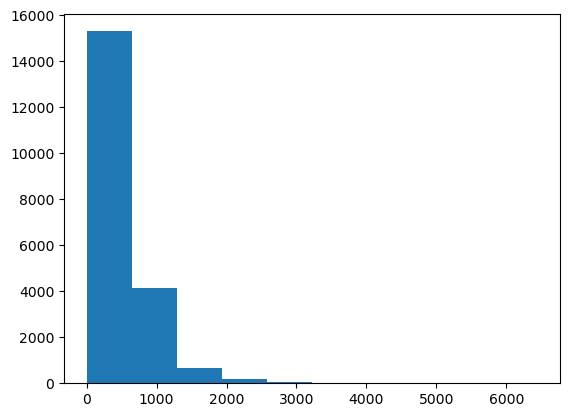

In [54]:
plt.hist(df['total_bedrooms'])

In [55]:
col= ['total_bedrooms']
imputer = KNNImputer(missing_values = np.nan,n_neighbors=5 )
df[col] = imputer.fit_transform(df[col])

(array([1.5511e+04, 4.1460e+03, 6.8200e+02, 1.7700e+02, 7.0000e+01,
        2.3000e+01, 1.8000e+01, 8.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([1.0000e+00, 6.4540e+02, 1.2898e+03, 1.9342e+03, 2.5786e+03,
        3.2230e+03, 3.8674e+03, 4.5118e+03, 5.1562e+03, 5.8006e+03,
        6.4450e+03]),
 <BarContainer object of 10 artists>)

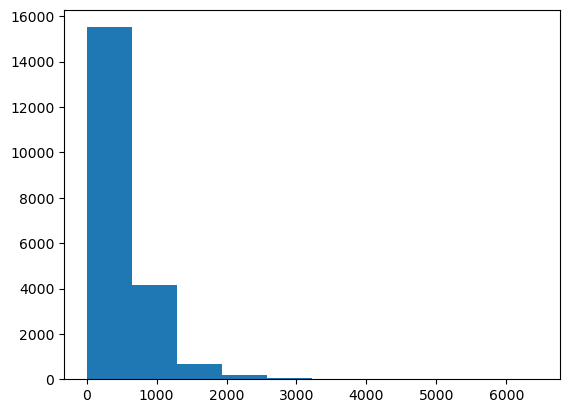

In [56]:
plt.hist(df['total_bedrooms'])

In [57]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

### outliers

In [58]:
cols_to_cap = ['median_house_value','median_income','housing_median_age']

In [59]:
def get_bounds(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

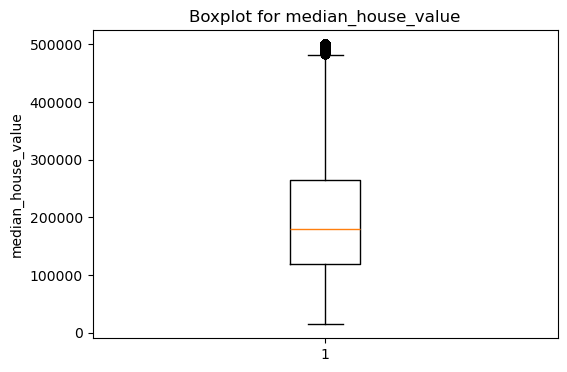

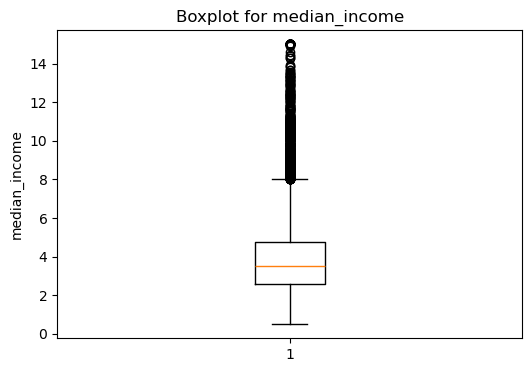

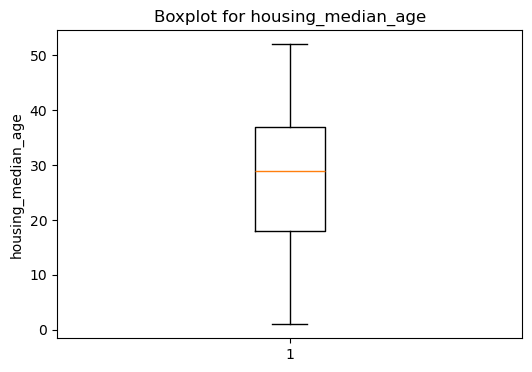

In [60]:
for col in cols_to_cap:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot for {col}')
    plt.ylabel(col)
    plt.show()
    

In [61]:
for col in cols_to_cap:
    lower, upper = get_bounds(df[col])
    df[col] = df[col].clip(lower=lower, upper=upper)
    

### split X,y /train,test

In [62]:
X = df.drop('median_house_value', axis=1).values
y = df['median_house_value'].values
X

array([[-1.222300e+02,  3.788000e+01,  4.100000e+01, ...,  3.220000e+02,
         1.260000e+02,  8.013025e+00],
       [-1.222200e+02,  3.786000e+01,  2.100000e+01, ...,  2.401000e+03,
         1.138000e+03,  8.013025e+00],
       [-1.222400e+02,  3.785000e+01,  5.200000e+01, ...,  4.960000e+02,
         1.770000e+02,  7.257400e+00],
       ...,
       [-1.212200e+02,  3.943000e+01,  1.700000e+01, ...,  1.007000e+03,
         4.330000e+02,  1.700000e+00],
       [-1.213200e+02,  3.943000e+01,  1.800000e+01, ...,  7.410000e+02,
         3.490000e+02,  1.867200e+00],
       [-1.212400e+02,  3.937000e+01,  1.600000e+01, ...,  1.387000e+03,
         5.300000e+02,  2.388600e+00]])

In [63]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.013025,452600.0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.013025,358500.0
2,-122.24,37.85,52,1467,190.0,496,177,7.257400,352100.0
3,-122.25,37.85,52,1274,235.0,558,219,5.643100,341300.0
4,-122.25,37.85,52,1627,280.0,565,259,3.846200,342200.0


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

### scaling data

In [65]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Models

In [78]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

In [79]:
results=[]
for name, model in models.items():
    pipeline = Pipeline([
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    #evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    #save results
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [80]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print(results_df.sort_values('R2', ascending=False))

               Model           MSE        RMSE         MAE      R2
4      Random Forest  2.165277e+09  46532.5403  31294.6289  0.8306
5                KNN  3.634597e+09  60287.6209  42329.6956  0.7156
1   Ridge Regression  4.442893e+09  66655.0289  50652.3560  0.6524
0  Linear Regression  4.442873e+09  66654.8763  50652.8473  0.6524
2   Lasso Regression  4.442875e+09  66654.8923  50652.8633  0.6524
3      Decision Tree  4.716074e+09  68673.6758  43486.3011  0.6310


In [81]:
results_df 

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,4.442873e+09,66654.8763,50652.8473,0.6524
1,Ridge Regression,4.442893e+09,66655.0289,50652.3560,0.6524
2,Lasso Regression,4.442875e+09,66654.8923,50652.8633,0.6524
3,Decision Tree,4.716074e+09,68673.6758,43486.3011,0.6310
4,Random Forest,2.165277e+09,46532.5403,31294.6289,0.8306
5,KNN,3.634597e+09,60287.6209,42329.6956,0.7156


C:\Users\User\AppData\Local\Temp\ipykernel_21300\1387188580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_21300\1387188580.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
C:\Users\User\AppData\Local\Temp\ipykernel_21300\1387188580.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missin

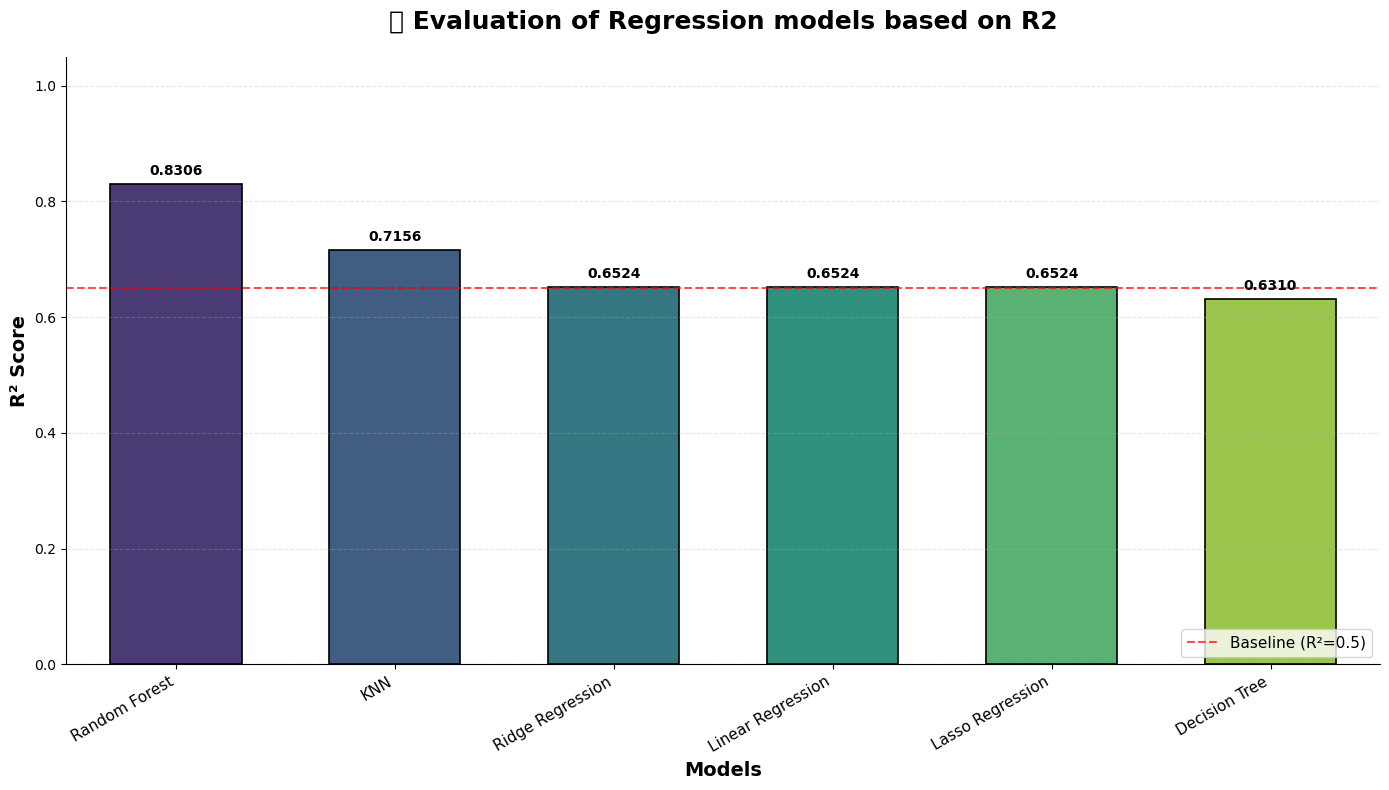

In [88]:
df_plot = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

#style
plt.figure(figsize=(14, 8))
palette = sns.color_palette("viridis", n_colors=len(df_plot))

#bar chart
ax = sns.barplot(
    data=df_plot,
    x='Model',
    y='R2',
    palette=palette,
    edgecolor='black',
    linewidth=1.2,
    width=0.6
)

#bars
for i, v in enumerate(df_plot['R2']):
    ax.text(
        i, 
        v + 0.01,
        f'{v:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )


ax.set_title('📊 Evaluation of Regression models based on R2', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# rotation of words
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)

# computing line
ax.axhline(y=0.65, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (R²=0.5)')
ax.legend(loc='lower right', fontsize=11)

# remove margin
sns.despine(top=True, right=True, left=False, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()